# Final visualisation of the unified results

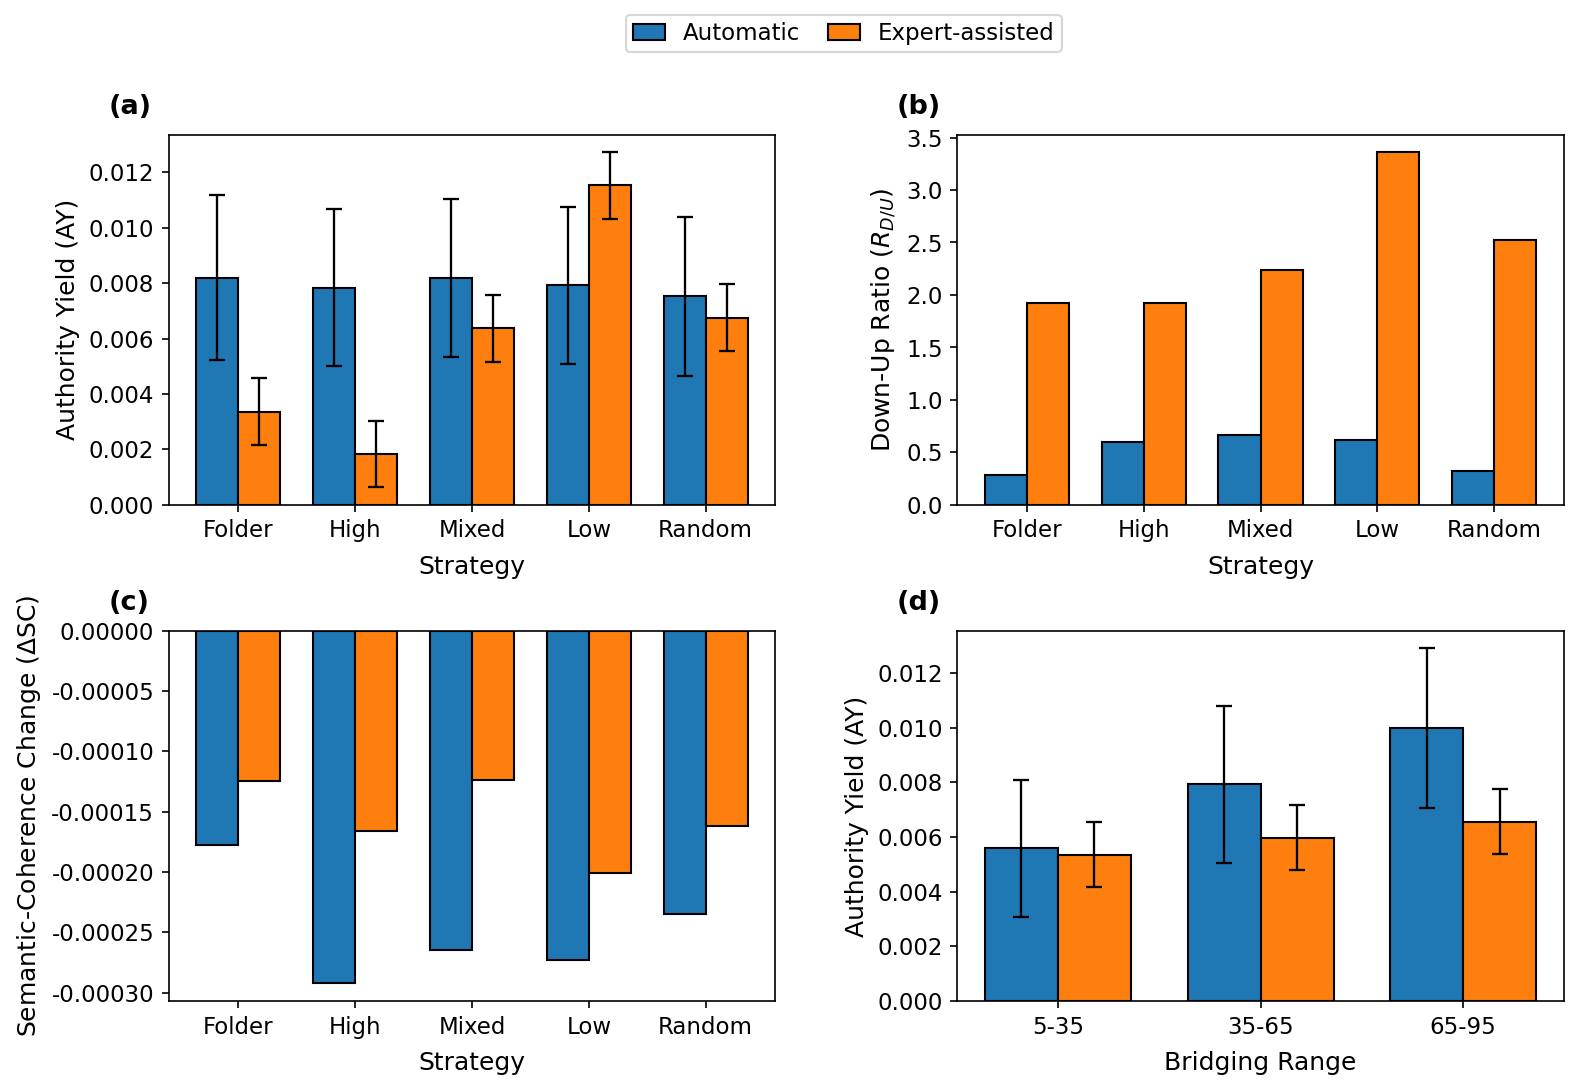

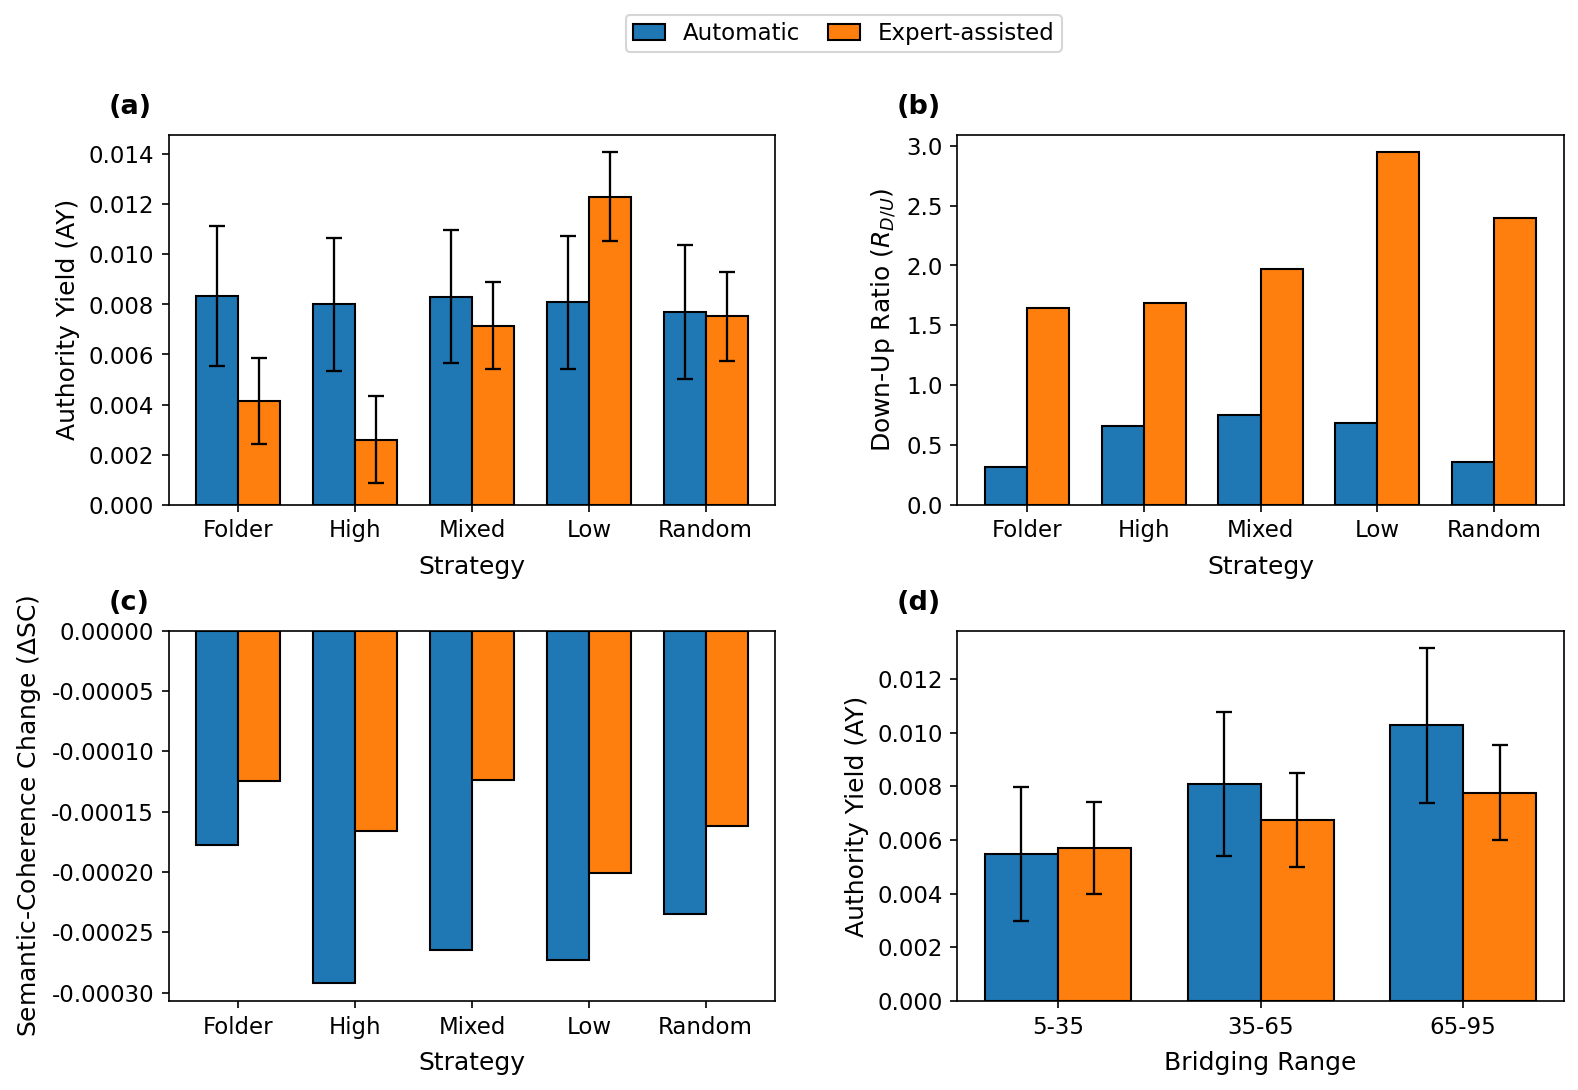

Saved files:
/content/WebKnoGraph/results_2026/webknograph_figure_BA_updated_ssa.png
/content/WebKnoGraph/results_2026/webknograph_figure_WWW_updated_ssa.png


In [5]:
# ==========================================
# WebKnoGraph figure generation
# Compact publication-ready version
#
# Final panel order:
# (a) Authority Yield by strategy, range 35-65
# (b) Down-Up Ratio by strategy, range 35-65
# (c) Semantic-Coherence Change by strategy
# (d) Authority Yield by bridging range, with AV error bars
#
# Uses new SSA paper-ready file:
# ssa_paper_strategy_values_repo_identity.csv
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter


# ==========================================
# 1. FILE PATHS
# ==========================================

AUTO_BA_PATH = "OVERALL_AVERAGES_TRACKER_AUTOMATIC_BA.csv"
AUTO_WWW_PATH = "OVERALL_AVERAGES_TRACKER_AUTOMATIC_WWW.csv"
EXPERT_BA_PATH = "OVERALL_AVERAGES_TRACKER_EXPERT_BA.csv"
EXPERT_WWW_PATH = "OVERALL_AVERAGES_TRACKER_EXPERT_WWW.csv"

SSA_PATH = "ssa_paper_strategy_values_repo_identity.csv"


# ==========================================
# 2. GLOBAL STYLE
# ==========================================

plt.rcParams.update(
    {
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12,
        "legend.fontsize": 11,
        "legend.title_fontsize": 11,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
    }
)

tab10 = plt.get_cmap("tab10")

AUTOMATIC_COLOR = tab10(0)
EXPERT_COLOR = tab10(1)

RANGE_ORDER = ["5-35", "35-65", "65-95"]
STRATEGY_ORDER = ["Folder", "High", "Mixed", "Low", "Random"]


# ==========================================
# 3. HELPER FUNCTIONS
# ==========================================


def normalize_strategy(s):
    s = str(s).strip().lower()

    if "folder" in s:
        return "Folder"
    if "high" in s:
        return "High"
    if "mixed" in s:
        return "Mixed"
    if "low" in s:
        return "Low"
    if "random" in s:
        return "Random"

    return str(s).title()


def normalize_range(r):
    r = str(r).strip()
    return r.replace("Range_", "")


def load_tracker(path, intervention_label):
    df = pd.read_csv(path).copy()

    df["StrategyLabel"] = df["Strategy"].apply(normalize_strategy)
    df["RangeLabel"] = df["Range"].apply(normalize_range)
    df["Intervention"] = intervention_label

    return df


def load_ssa_summary(path):
    """
    Loads the new paper-ready SSA file:
    ssa_paper_strategy_values_repo_identity.csv

    Expected columns:
    - Regime
    - Strategy
    - Mean_Delta_SC
    - Std_Delta_SC
    - Mean_Added_Link_Similarity
    - Mean_Added_Edges
    - Total_Removed_Edges
    - Max_Removed_Edges
    """
    df = pd.read_csv(path).copy()

    required_cols = {"Regime", "Strategy", "Mean_Delta_SC"}
    missing = required_cols - set(df.columns)

    if missing:
        raise ValueError(
            f"SSA file is missing required columns: {missing}. "
            f"Available columns: {list(df.columns)}"
        )

    df["StrategyLabel"] = df["Strategy"].apply(normalize_strategy)

    df["Intervention"] = df["Regime"].map(
        {
            "automatic": "Automatic",
            "expert": "Expert-assisted",
            "Automatic": "Automatic",
            "Expert": "Expert-assisted",
            "Expert-assisted": "Expert-assisted",
        }
    )

    df = df.rename(columns={"Mean_Delta_SC": "delta_ssa"})

    return df[["Intervention", "StrategyLabel", "delta_ssa"]]


def add_panel_label(ax, label):
    """
    Place panel labels outside the plotting area, top-left.
    """
    ax.text(
        -0.10,
        1.04,
        label,
        transform=ax.transAxes,
        ha="left",
        va="bottom",
        fontsize=13,
        fontweight="bold",
        clip_on=False,
    )


def prepare_aggregate_by_range(df):
    """
    Aggregate AY and AV by bridging range across all strategies.
    Used for panel (d).
    """
    out = (
        df.groupby("RangeLabel", as_index=False)
        .agg(
            Overall_Avg_AY=("Overall_Avg_AY", "mean"),
            Overall_Avg_AV=("Overall_Avg_AV", "mean"),
        )
        .set_index("RangeLabel")
        .reindex(RANGE_ORDER)
        .reset_index()
    )

    return out


def prepare_strategy_level(df, range_value="35-65"):
    """
    Extract per-strategy values for one bridging range.
    Default is the representative middle range 35-65.
    """
    out = (
        df[df["RangeLabel"] == range_value]
        .set_index("StrategyLabel")
        .reindex(STRATEGY_ORDER)
        .reset_index()
    )

    return out


def prepare_semantic_coherence(ssa_summary, intervention_label):
    """
    Extract semantic-coherence change by strategy for one intervention type.
    """
    out = (
        ssa_summary[ssa_summary["Intervention"] == intervention_label]
        .set_index("StrategyLabel")
        .reindex(STRATEGY_ORDER)
        .reset_index()
    )

    return out


# ==========================================
# 4. MAIN PLOTTING FUNCTION
# ==========================================


def plot_webknograph_figure(auto_df, expert_df, ssa_summary, output_file):
    fig, axs = plt.subplots(2, 2, figsize=(12, 7.6), dpi=150)

    bar_width = 0.36

    err_kw = dict(ecolor="black", elinewidth=1.1, capsize=4, capthick=1.1)

    # Prepare shared data
    auto_strategy = prepare_strategy_level(auto_df, range_value="35-65")
    expert_strategy = prepare_strategy_level(expert_df, range_value="35-65")

    auto_range = prepare_aggregate_by_range(auto_df)
    expert_range = prepare_aggregate_by_range(expert_df)

    auto_sc = prepare_semantic_coherence(ssa_summary, "Automatic")
    expert_sc = prepare_semantic_coherence(ssa_summary, "Expert-assisted")

    # --------------------------
    # Panel (a)
    # Authority Yield by strategy at range 35-65
    # --------------------------

    ax = axs[0, 0]

    x = np.arange(len(STRATEGY_ORDER))

    bars_auto = ax.bar(
        x - bar_width / 2,
        auto_strategy["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=auto_strategy["Overall_Avg_AV"].to_numpy(),
        color=AUTOMATIC_COLOR,
        edgecolor="black",
        label="Automatic",
        error_kw=err_kw,
    )

    bars_expert = ax.bar(
        x + bar_width / 2,
        expert_strategy["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=expert_strategy["Overall_Avg_AV"].to_numpy(),
        color=EXPERT_COLOR,
        edgecolor="black",
        label="Expert-assisted",
        error_kw=err_kw,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=6)
    ax.set_ylabel("Authority Yield (AY)")

    add_panel_label(ax, "(a)")

    # --------------------------
    # Panel (b)
    # Down-Up Ratio by strategy at range 35-65
    # --------------------------

    ax = axs[0, 1]

    x = np.arange(len(STRATEGY_ORDER))

    ax.bar(
        x - bar_width / 2,
        auto_strategy["Overall_Avg_DUR"].to_numpy(),
        width=bar_width,
        color=AUTOMATIC_COLOR,
        edgecolor="black",
    )

    ax.bar(
        x + bar_width / 2,
        expert_strategy["Overall_Avg_DUR"].to_numpy(),
        width=bar_width,
        color=EXPERT_COLOR,
        edgecolor="black",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=6)
    ax.set_ylabel(r"Down-Up Ratio ($R_{D/U}$)")

    add_panel_label(ax, "(b)")

    # --------------------------
    # Panel (c)
    # Semantic-Coherence Change by strategy
    # --------------------------

    ax = axs[1, 0]

    x = np.arange(len(STRATEGY_ORDER))

    ax.bar(
        x - bar_width / 2,
        auto_sc["delta_ssa"].to_numpy(),
        width=bar_width,
        color=AUTOMATIC_COLOR,
        edgecolor="black",
    )

    ax.bar(
        x + bar_width / 2,
        expert_sc["delta_ssa"].to_numpy(),
        width=bar_width,
        color=EXPERT_COLOR,
        edgecolor="black",
    )

    ax.set_xticks(x)
    ax.set_xticklabels(STRATEGY_ORDER)
    ax.set_xlabel("Strategy", labelpad=6)
    ax.set_ylabel(r"Semantic-Coherence Change ($\Delta$SC)")
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.5f"))

    add_panel_label(ax, "(c)")

    # --------------------------
    # Panel (d)
    # Authority Yield by bridging range
    # AV used as error bars
    # --------------------------

    ax = axs[1, 1]

    x = np.arange(len(RANGE_ORDER))

    ax.bar(
        x - bar_width / 2,
        auto_range["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=auto_range["Overall_Avg_AV"].to_numpy(),
        color=AUTOMATIC_COLOR,
        edgecolor="black",
        error_kw=err_kw,
    )

    ax.bar(
        x + bar_width / 2,
        expert_range["Overall_Avg_AY"].to_numpy(),
        width=bar_width,
        yerr=expert_range["Overall_Avg_AV"].to_numpy(),
        color=EXPERT_COLOR,
        edgecolor="black",
        error_kw=err_kw,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(RANGE_ORDER)
    ax.set_xlabel("Bridging Range", labelpad=6)
    ax.set_ylabel("Authority Yield (AY)")

    add_panel_label(ax, "(d)")

    # --------------------------
    # Shared legend above all panels
    # --------------------------

    fig.legend(
        handles=[bars_auto, bars_expert],
        labels=["Automatic", "Expert-assisted"],
        loc="upper center",
        bbox_to_anchor=(0.5, 0.955),
        ncol=2,
        frameon=True,
        handlelength=1.4,
        columnspacing=1.2,
        borderpad=0.3,
        labelspacing=0.3,
    )

    # --------------------------
    # Final layout
    # --------------------------

    plt.subplots_adjust(top=0.84, bottom=0.08, hspace=0.34, wspace=0.30)

    plt.savefig(output_file, bbox_inches="tight", pad_inches=0.14, dpi=300)
    plt.show()


# ==========================================
# 5. LOAD DATA
# ==========================================

auto_ba = load_tracker(AUTO_BA_PATH, "Automatic")
auto_www = load_tracker(AUTO_WWW_PATH, "Automatic")

expert_ba = load_tracker(EXPERT_BA_PATH, "Expert-assisted")
expert_www = load_tracker(EXPERT_WWW_PATH, "Expert-assisted")

ssa_summary = load_ssa_summary(SSA_PATH)


# ==========================================
# 6. GENERATE FIGURES
# ==========================================

plot_webknograph_figure(
    auto_df=auto_ba,
    expert_df=expert_ba,
    ssa_summary=ssa_summary,
    output_file="webknograph_figure_BA_updated_ssa.png",
)

plot_webknograph_figure(
    auto_df=auto_www,
    expert_df=expert_www,
    ssa_summary=ssa_summary,
    output_file="webknograph_figure_WWW_updated_ssa.png",
)


# ==========================================
# 7. CONFIRM OUTPUT
# ==========================================

print("Saved files:")
print("/content/WebKnoGraph/results_2026/webknograph_figure_BA_updated_ssa.png")
print("/content/WebKnoGraph/results_2026/webknograph_figure_WWW_updated_ssa.png")